Artificial Neural Networks for Predicting Diabetes Likelihood

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
import tensorflow as tf
from tensorflow.keras.metrics import Precision, AUC
import shap

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Importing the clean training and testing dataset

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [3]:
# Identify binary columns and continuous columns for scaling as we need to scale only continuous variabels

binary_cols = [c for c in train.columns if set(pd.unique(train[c].dropna())) <= {0, 1}]
cont_cols   = [c for c in train.columns if c not in binary_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("scale", StandardScaler(), cont_cols),
        ("keep_bin", "passthrough", binary_cols),
    ]
)

# Fitting the data (it becomes a scaled array)

train_scaled_array = preprocess.fit_transform(train) 
test_scaled_array = preprocess.transform(test)

# Convert the arrays back into dataframes for data manipulation

new_cols = cont_cols + binary_cols  
train_scaled = pd.DataFrame(train_scaled_array, columns=new_cols, index=train.index)
test_scaled  = pd.DataFrame(test_scaled_array,  columns=new_cols, index=test.index)


In [4]:
train_scaled.head()

,age,bmi,HbA1c_level,blood_glucose_level,hypertension,heart_disease,diabetes,female,male,other,current,ever,former,never,no info,not current
0,0.141014,2.521511,-1.429243,1.514969,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.141014,0.390141,0.435572,0.486562,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.674635,0.403462,2.486868,2.984121,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1.697407,-0.447605,0.622053,0.486562,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.926226,0.829736,-0.683317,0.045817,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [5]:
# Splitting the scaled data into "X" matrix (input) and "Y" matrix (true outcome)

# We drop HbA1c_level because it is highly correlated with blood glucose level which could lead to multicollinearity
# "Other" is also dropped because it has very little effect on the model

train_input = train_scaled.drop(['HbA1c_level','diabetes','other'], axis = 1)
train_output = train_scaled[['diabetes']]

test_input = test_scaled.drop(['HbA1c_level','diabetes','other'], axis = 1)
test_output = test_scaled[['diabetes']]

In [6]:
print(f'Training input: {len(train_input)} rows.')
print(f'Training output: {len(train_output)} rows.')

Training input: 76889 rows.
Training output: 76889 rows.


In [7]:
# First Test 
# Initialising and adding layers: Architecture 14 14 14 1

# Compiling ANN
# Use "adam" for back propagation optimiser
# Use "binary_crossentropy" for calculating loss in classification problem
# Measure metrics such as "accuracy", "precision", "AUC"

ann = tf.keras.models.Sequential()
ann.add(tf.keras.layers.Dense(units=14, activation='relu'))
ann.add(tf.keras.layers.Dense(units=14, activation='relu'))
ann.add(tf.keras.layers.Dense(units=1, activation="sigmoid"))

# Early stopping function, if there is no improvements during 10 consecutive epochs, stop the iteration.

callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                              patience=10)

ann.compile(optimizer="adam", loss="binary_crossentropy", 
            metrics=['accuracy', Precision(), AUC()])

# Fitting ANN, try 100 epochs with early stopping

model = ann.fit(train_input, train_output, batch_size=32, verbose = 0, 
                validation_split = 0.2, epochs = 100, callbacks=[callback])



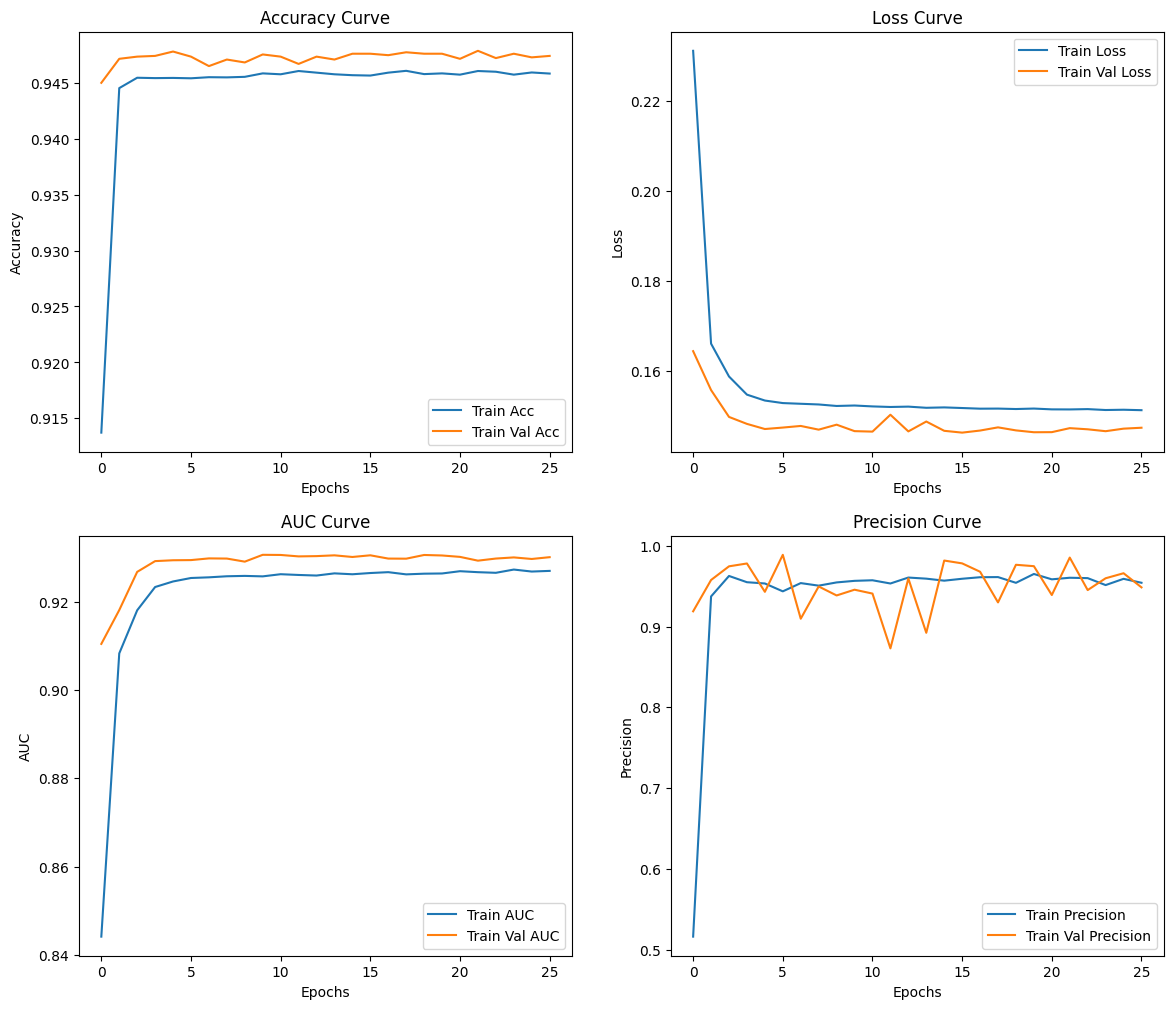

In [ ]:
# Plotting Accuracy, Loss, AUC, and Precision in a 2x2 subplot

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(14, 12))

# Accuracy Curve

ax1.plot(model.history['accuracy'], label = 'Train Acc')
ax1.plot(model.history['val_accuracy'], label = 'Train Val Acc')
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Accuracy")
ax1.set_title("Accuracy Curve")
ax1.legend() 

# Loss Curve

ax2.plot(model.history['loss'], label = 'Train Loss')
ax2.plot(model.history['val_loss'], label = 'Train Val Loss')
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Loss")
ax2.set_title("Loss Curve")
ax2.legend() 

# AUC Curve

ax3.plot(model.history['auc'], label = 'Train AUC')
ax3.plot(model.history['val_auc'], label = 'Train Val AUC')
ax3.set_xlabel("Epochs")
ax3.set_ylabel("AUC")
ax3.set_title("AUC Curve")
ax3.legend() 

# Precision Curve

ax4.plot(model.history['precision'], label = 'Train Precision')
ax4.plot(model.history['val_precision'], label = 'Train Val Precision')
ax4.set_xlabel("Epochs")
ax4.set_ylabel("Precision")
ax4.set_title("Precision Curve")
ax4.legend() 

# Save the plot

# plt.savefig("Training_Metrics_Plot")

plt.show()


In [9]:
# Evaluate the trained ANN model on the test dataset

ann.evaluate(test_input, test_output)

601/601 ━━━━━━━━━━━━━━━━━━━━ 0s 775us/step - accuracy: 0.9461 - auc: 0.9301 - loss: 0.1507 - precision: 0.9534


[0.15068985521793365,
 0.946054220199585,
 0.9533954858779907,
 0.9300985932350159]

In [10]:
# Predict diabetes probabilities on the test dataset
# .squeeze() removes extra dimensions so we get a 1D array

y_pred_proba = ann.predict(test_input, verbose=0).squeeze()
y_pred = pd.DataFrame({"diabetes_pred": y_pred_proba}, index = test_output.index)

# Combine actual labels with predicted probabilities for comparison
prediction_binary = pd.concat([test_output, y_pred], axis = 1)


In [ ]:
# Save the training history metrics

# pd.DataFrame(model.history).to_csv("training_history.csv", index=False)

In [12]:
# Extract feature names for reference in SHAP plots

feature_names = train_input.columns.tolist()

# Convert train/test inputs to numpy arrays (float32 for compatibility with SHAP and TensorFlow)

train_i = train_input.to_numpy(dtype=np.float32)

test_i = test_input.to_numpy(dtype=np.float32)

# Select a random subset of training data as background for SHAP

bg_idx = np.random.choice(train_i.shape[0], size=min(200, train_i.shape[0]), replace=False)
background = train_i[bg_idx]

# Create a SHAP masker that independently perturbs features using the background distribution
# Build a SHAP explainer for the ANN model

masker = shap.maskers.Independent(background)
explainer = shap.Explainer(ann, masker) 

# Choose the first 200 test samples to explain and calculate the SHAP values

x_explain = test_i[:200]
shap_values = explainer(x_explain)  

# Attact the feature names to the SHAP values

shap_values.feature_names = feature_names

PermutationExplainer explainer: 201it [00:15,  6.64it/s]                         


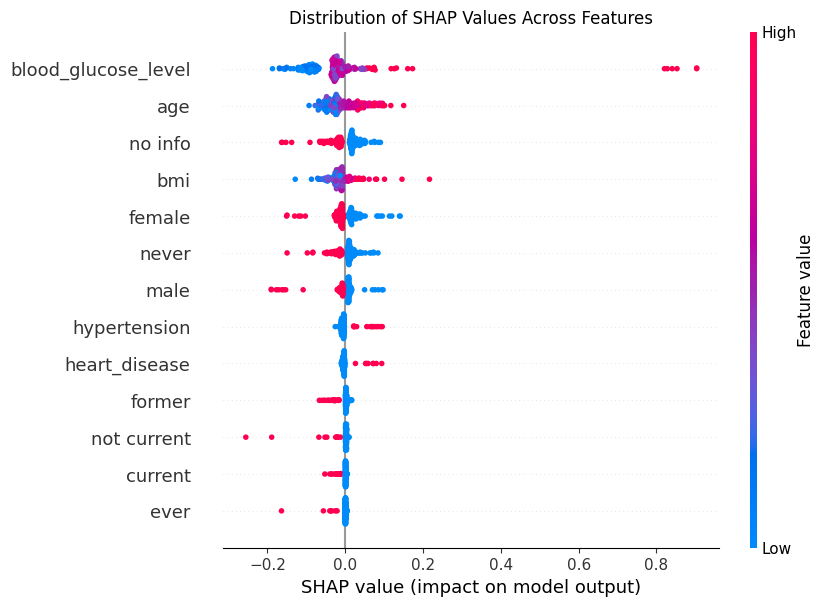

In [ ]:
shap.plots.beeswarm(shap_values, max_display=20, show = False)
plt.title("Distribution of SHAP Values Across Features");

# plt.savefig("SHAP_Beeswarm_Plot")

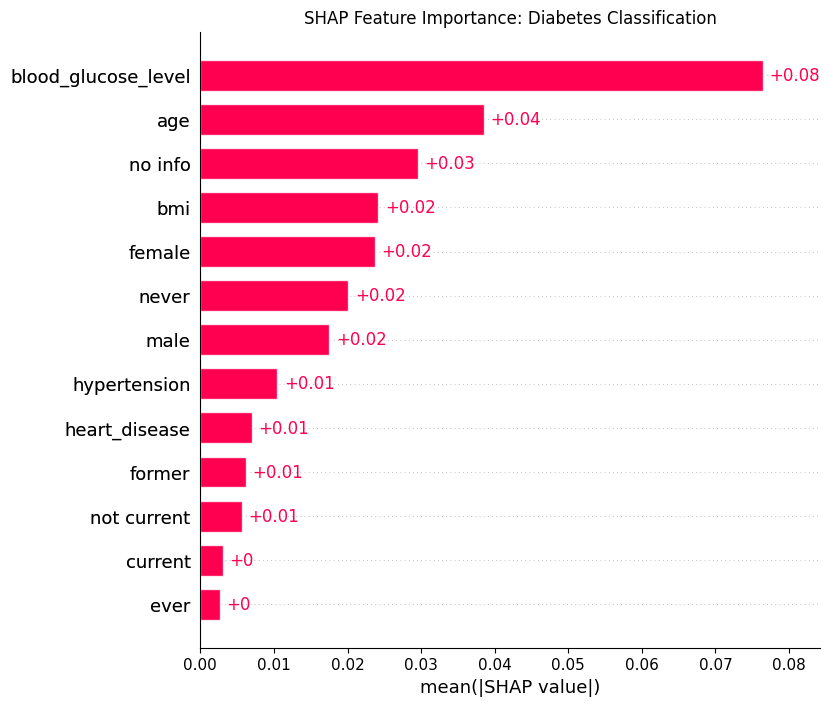

In [ ]:
shap.plots.bar(shap_values, max_display=15, show = False)
plt.title("SHAP Feature Importance: Diabetes Classification");

# plt.savefig("SHAP_Bar_Plot")